<a href="https://colab.research.google.com/github/cafercanservi/kaggle-covid/blob/main/covid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import export_graphviz
import graphviz
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

In [36]:
df = pd.read_csv('covid.csv')

In [37]:
df.head(10)


,Patient_ID,Name,Age,Gender,Blood_Pressure,Heart_Rate,Fever,Cough,Sore_Throat,Fatigue,...,Asthma,Obesity,Smoking,Vaccinated,Travel_History,Contact_with_Positive,Comorbidity_Count,ICU_Admission,Hospitalization_Days,Is_Covid_True
0,1,Christina Curtis,52.0,Other,95.0,79.0,False,True,False,False,...,False,False,False,True,False,False,NaN,False,NaN,True
1,2,Joe Case,93.0,Other,118.0,66.0,False,False,False,False,...,False,False,False,True,False,True,0.0,False,7.0,True
2,3,Melissa Dean,15.0,Other,153.0,79.0,False,False,False,False,...,False,True,False,True,False,False,4.0,False,22.0,True
3,4,Victoria Myers,NaN,Other,154.0,116.0,True,False,False,False,...,False,False,False,True,False,False,0.0,False,16.0,True
4,5,Tina Hill,61.0,Male,145.0,93.0,False,False,False,False,...,False,False,False,False,False,False,2.0,False,14.0,False
5,6,Robert Ellis,21.0,Other,NaN,70.0,True,True,False,True,...,False,False,False,True,False,True,0.0,False,29.0,True
6,7,William Arellano,83.0,Other,125.0,NaN,True,False,True,True,...,False,True,False,False,False,False,4.0,False,12.0,True
7,8,Carrie Adams,87.0,Other,160.0,118.0,False,True,False,False,...,False,False,True,False,False,False,NaN,False,NaN,True
8,9,James Campbell,75.0,Male,129.0,70.0,False,True,False,True,...,False,False,False,True,False,False,0.0,False,25.0,True
9,10,Alexander Stark,75.0,Other,127.0,74.0,False,False,False,False,...,False,False,False,True,False,False,3.0,False,13.0,False


In [38]:
for column in df.columns:
    if df[column].isnull().any():
        if df[column].dtype == 'object':
            df[column] = df[column].fillna(df[column].mode()[0])
        else:

            df[column] = df[column].fillna(df[column].mean())

<ipython-input-38-9a56d78c652f>:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[column] = df[column].fillna(df[column].mode()[0])


In [39]:
df.replace({'True': 1, 'False': 0, 'Fals': 0, 'TRUE': 1, 'FALSE': 0, True: 1, False: 0}, inplace=True)



<ipython-input-39-fbba8d8b0042>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'True': 1, 'False': 0, 'Fals': 0, 'TRUE': 1, 'FALSE': 0, True: 1, False: 0}, inplace=True)


In [40]:
df =pd.get_dummies(df, columns=['Gender'], drop_first=True)
df.head(3)

,Patient_ID,Name,Age,Blood_Pressure,Heart_Rate,Fever,Cough,Sore_Throat,Fatigue,Headache,...,Smoking,Vaccinated,Travel_History,Contact_with_Positive,Comorbidity_Count,ICU_Admission,Hospitalization_Days,Is_Covid_True,Gender_Male,Gender_Other
0,1,Christina Curtis,52.0,95.0,79.0,0,1,0,0,0,...,0,1,0,0,2.008542,0,14.476562,1,False,True
1,2,Joe Case,93.0,118.0,66.0,0,0,0,0,1,...,0,1,0,1,0.000000,0,7.000000,1,False,True
2,3,Melissa Dean,15.0,153.0,79.0,0,0,0,0,1,...,0,1,0,0,4.000000,0,22.000000,1,False,True


In [41]:
columns_to_drop = ["Patient_ID", "Name", "Comorbidity_Count", "Hospitalization_Days",
                   "ICU_Admission", "Travel_History", "Contact_with_Positive", "Gender_Other"]


existing_columns = [col for col in columns_to_drop if col in df.columns]

df = df.drop(columns=existing_columns)
df.head(4)

,Age,Blood_Pressure,Heart_Rate,Fever,Cough,Sore_Throat,Fatigue,Headache,Breathlessness,Loss_of_Smell_Taste,...,Runny_Nose,Vomiting,Diabetes,Hypertension,Asthma,Obesity,Smoking,Vaccinated,Is_Covid_True,Gender_Male
0,52.000000,95.0,79.0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,False
1,93.000000,118.0,66.0,0,0,0,0,1,0,1,...,1,0,0,0,0,0,0,1,1,False
2,15.000000,153.0,79.0,0,0,0,0,1,1,0,...,0,0,0,0,0,1,0,1,1,False
3,49.989894,154.0,116.0,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,1,1,False


In [42]:
y=df["Is_Covid_True"]
x=df.drop("Is_Covid_True",axis=1)

In [43]:
x_test,x_train,y_test,y_train=train_test_split(x,y,train_size=0.75,random_state=10)

In [44]:
tree= RandomForestClassifier(n_estimators=300,max_depth=10)
model=tree.fit(x_train, y_train)
model.score(x_test, y_test)

0.9285809047892805

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30151 entries, 0 to 30150
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  30151 non-null  float64
 1   Blood_Pressure       30151 non-null  float64
 2   Heart_Rate           30151 non-null  float64
 3   Fever                30151 non-null  int64  
 4   Cough                30151 non-null  int64  
 5   Sore_Throat          30151 non-null  int64  
 6   Fatigue              30151 non-null  int64  
 7   Headache             30151 non-null  int64  
 8   Breathlessness       30151 non-null  int64  
 9   Loss_of_Smell_Taste  30151 non-null  int64  
 10  Diarrhea             30151 non-null  int64  
 11  Chest_Pain           30151 non-null  int64  
 12  Body_Ache            30151 non-null  int64  
 13  Runny_Nose           30151 non-null  int64  
 14  Vomiting             30151 non-null  int64  
 15  Diabetes             30151 non-null 

In [46]:
model.predict([[22,100,88,1,0,1,1,1,0,0,0,0,1,1,0,0,0,0,1,0,1,1]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([1])

In [47]:
human = df.sample().drop("Is_Covid_True", axis=1).values
human

array([[6.0, 146.0, 94.0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
        0, 0, False]], dtype=object)

In [48]:
model.predict(human)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([1])

In [49]:
from sklearn.tree import export_graphviz
import graphviz


estimator = model.estimators_[0]

dot = export_graphviz(
    estimator,
    feature_names=x.columns,
    filled=True,
    rounded=True,
    special_characters=True,
    out_file=None
)

gorsel = graphviz.Source(dot)
gorsel.render("random_forest_tree_0", format='pdf', cleanup=True)

'random_forest_tree_0.pdf'

<ipython-input-50-bdf5a228aba2>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")


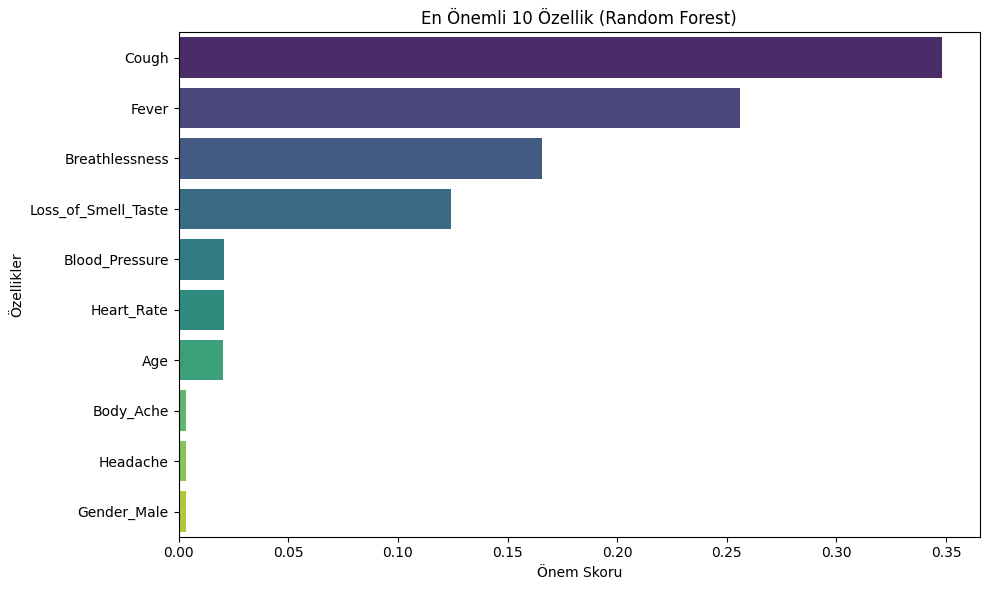

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

importances = model.feature_importances_
feature_names = x.columns
feat_importances = pd.Series(importances, index=feature_names)

top_features = feat_importances.sort_values(ascending=False).head(10)


plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title("En Önemli 10 Özellik (Random Forest)")
plt.xlabel("Önem Skoru")
plt.ylabel("Özellikler")
plt.tight_layout()
plt.show()


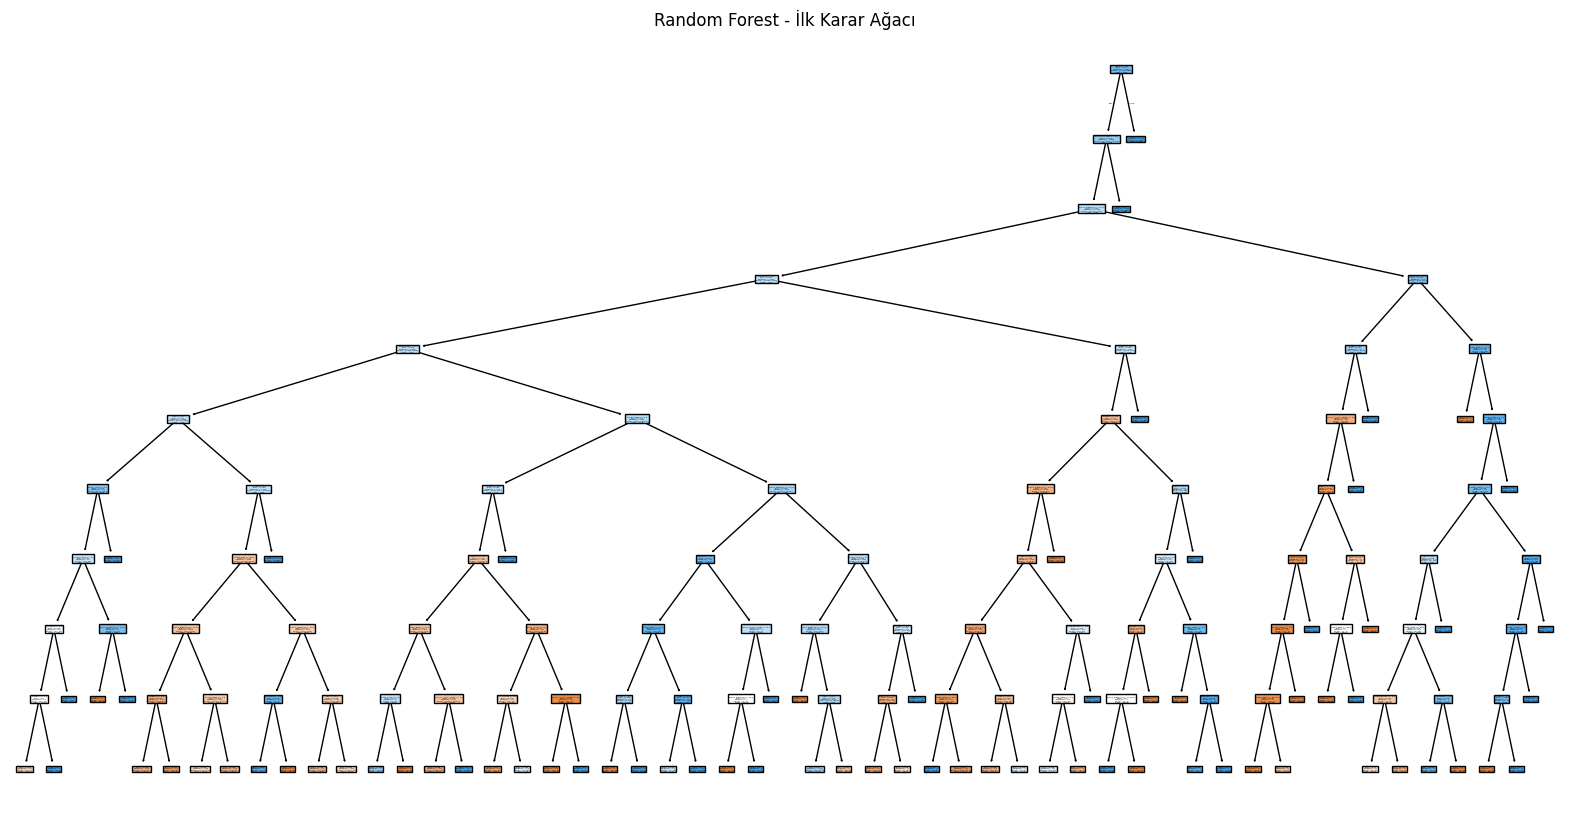

In [51]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(model.estimators_[0], feature_names=x.columns, class_names=['False', 'True'], filled=True)
plt.title("Random Forest - İlk Karar Ağacı")
plt.show()
